# 📘 Regression Evaluation Metrics on California Housing Dataset

## 1. Data Loading and Preprocessing

### 📌 Objective
The objective is to apply multiple regression algorithms to the California Housing dataset and evaluate their performance using appropriate regression metrics.

### 📥 Import Libraries

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

### 📊 Load and Explore the Dataset

In [97]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [98]:
df['MedHouseVal'] = data.target

### 🧹 Data Overview, Cleaning, and Summary

In [100]:
# Basic structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [101]:
# Statistical summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [102]:
# First 5 rows
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [103]:

# Last 5 rows
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [104]:
# Remove duplicate rows
df = df.drop_duplicates()

In [105]:
df.shape

(20640, 9)

In [106]:
# Check for missing values
print("Missing values in dataset:", df.isnull().sum())

Missing values in dataset: MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


No missing values found

In [108]:
# Check skewness of numerical features
print("Skewness of features:", df.skew())

Skewness of features: MedInc          1.646657
HouseAge        0.060331
AveRooms       20.697869
AveBedrms      31.316956
Population      4.935858
AveOccup       97.639561
Latitude        0.465953
Longitude      -0.297801
MedHouseVal     0.977763
dtype: float64


In [109]:

# Many features, such as `AveRooms`, `AveBedrms`, and `AveOccup`, exhibit extreme skewness. These may benefit from transformations like log or square root to normalize distributions. However, since tree-based models (like Decision Tree, Random Forest) are not sensitive to feature distribution, transformations are most helpful for models like **Linear Regression** and **SVR**.

###✅ **Optional Step** (not mandatory for assignment): You could apply `np.log1p()` to highly skewed features before training.

# Apply log transformation to reduce skewness 
df['AveRooms'] = np.log1p(df['AveRooms'])
df['AveBedrms'] = np.log1p(df['AveBedrms'])
df['Population'] = np.log1p(df['Population'])
df['AveOccup'] = np.log1p(df['AveOccup'])


In [110]:
# Check skewness of numerical features
print("Skewness of features:", df.skew())

Skewness of features: MedInc         1.646657
HouseAge       0.060331
AveRooms       1.390761
AveBedrms      8.988786
Population    -1.044087
AveOccup       3.879679
Latitude       0.465953
Longitude     -0.297801
MedHouseVal    0.977763
dtype: float64


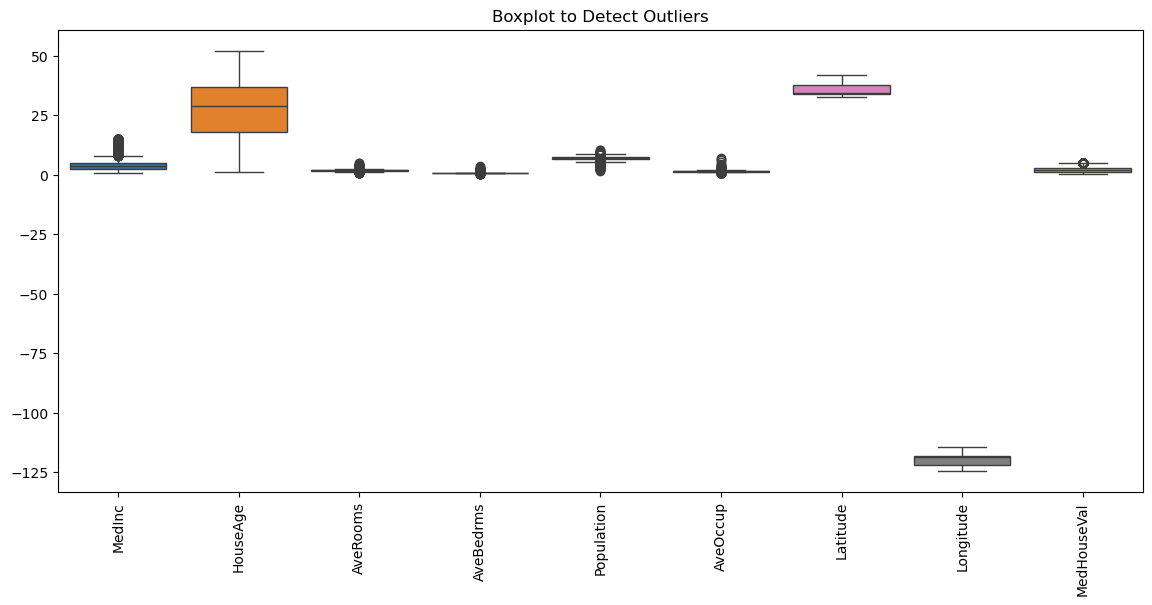

In [111]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot to Detect Outliers")
plt.show()

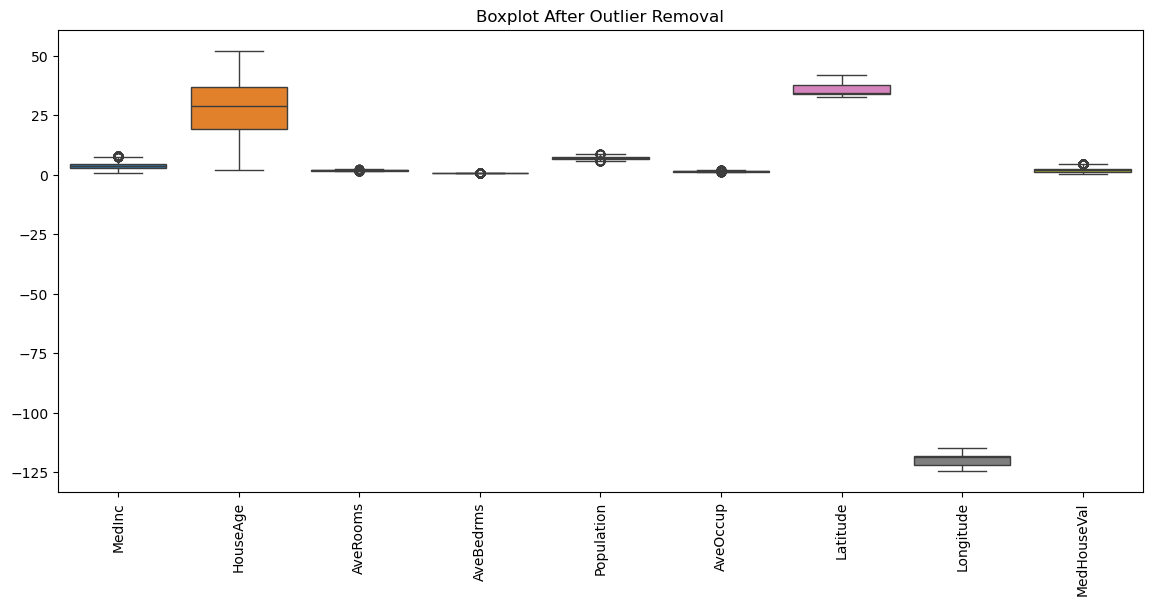

In [112]:
# Handle outliers using IQR
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Visualize outliers after removal
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Removal")
plt.show()

In [113]:
df.shape

(16788, 9)

### ⚖️ Feature Scaling

In [118]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('MedHouseVal', axis=1))
X = pd.DataFrame(X_scaled, columns=data.feature_names)
y = df['MedHouseVal']

**Preprocessing Steps Explained and Justified:**

- **Missing Value Handling**: Checked for missing values using `isnull().sum()`. The California Housing dataset is clean with no missing values, so no imputation is needed.
- **Feature Scaling**: Used `StandardScaler` to standardize features. This centers features around the mean with unit variance.
  - **Why Standardization?** Models like Support Vector Regressor (SVR) and Gradient Boosting are sensitive to the scale of features. Standardization improves convergence speed and model performance.
- **EDA**: Used correlation heatmap to understand relationships between features and the target variable, which helps in selecting features or understanding multicollinearity.

### 📈 Exploratory Data Analysis (EDA)

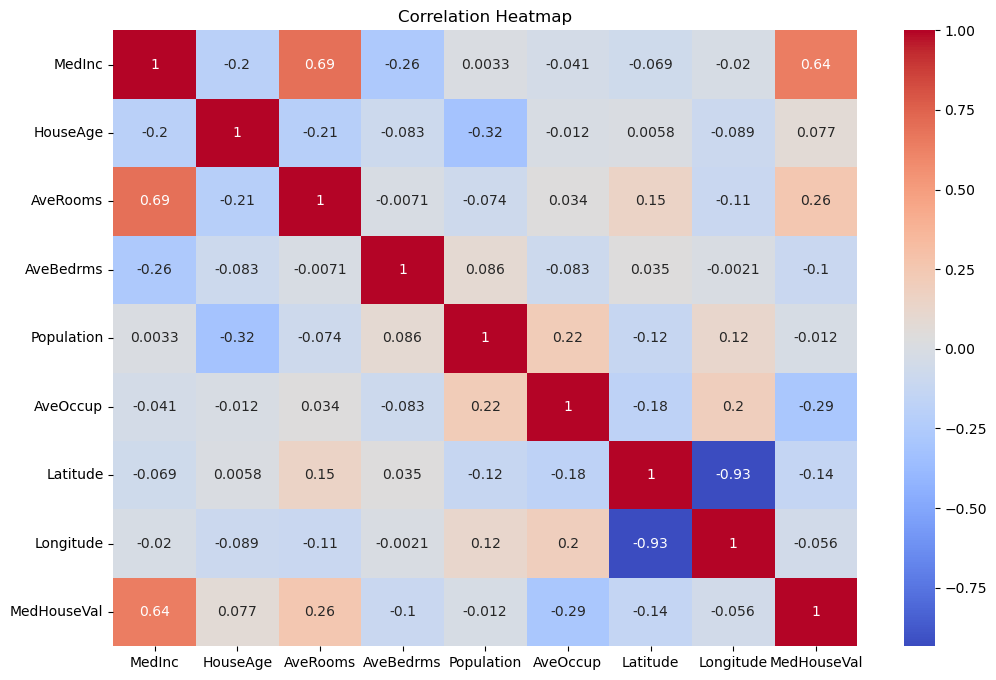

In [121]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 2. Regression Algorithm Implementation

### 🤖 Train/Test Split

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 🔧 Define and Train Models

In [129]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

### 📘 Model Explanations
- **Linear Regression**: Fits a linear model to predict the target. It assumes a linear relationship between features and the target. Suitable as a baseline model.
- **Decision Tree Regressor**: Splits data into branches based on feature values. Good at capturing non-linear relationships but can overfit without constraints.
- **Random Forest Regressor**: An ensemble of decision trees trained on bootstrapped samples. Reduces overfitting and improves generalization.
- **Gradient Boosting Regressor**: Builds trees sequentially to minimize the error from the previous tree. Good for handling complex, non-linear relationships.
- **Support Vector Regressor (SVR)**: Tries to fit the data within a margin of tolerance. Effective with high-dimensional data and sensitive to feature scaling.


## 3. Model Evaluation and Comparison

### 📋 Print Evaluation Metrics

In [136]:
print("\nModel Evaluation Metrics:\n")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  MSE: {metrics['MSE']:.4f}")
    print(f"  R2: {metrics['R2']:.4f}\n")


Model Evaluation Metrics:

Linear Regression:
  MAE: 0.3920
  MSE: 0.2711
  R2: 0.6859

Decision Tree:
  MAE: 0.4033
  MSE: 0.3599
  R2: 0.5830

Random Forest:
  MAE: 0.2788
  MSE: 0.1661
  R2: 0.8075

Gradient Boosting:
  MAE: 0.3079
  MSE: 0.1838
  R2: 0.7871

SVR:
  MAE: 0.3162
  MSE: 0.1996
  R2: 0.7687



| Model             | MAE        | MSE        | R² Score   |
| ----------------- | ---------- | ---------- | ---------- |
| Linear Regression | 0.3920     | 0.2711     | 0.6859     |
| Decision Tree     | 0.4033     | 0.3599     | 0.5830     |
| Random Forest     | **0.2788** | **0.1661** | **0.8075** |
| Gradient Boosting | 0.3079     | 0.1838     | 0.7871     |
| SVR               | 0.3162     | 0.1996     | 0.7687     |

<br>🥇 Best Performing Model: Random Forest Regressor
Justification:

Lowest MAE: 0.2788 → smallest average error in predictions.

Lowest MSE: 0.1661 → minimal squared errors, meaning less penalty for large deviations.

Highest R²: 0.8075 → explains over 80% of the variance in housing prices.

Why Random Forest works well here:

It captures complex nonlinear interactions without overfitting.

Less sensitive to outliers and skewed features due to decision-tree structure.

Ensemble nature reduces variance and improves robustness.

🥈 Runner-Up: Gradient Boosting Regressor
Performs well across all metrics and handles complex patterns.

However, it's slightly behind Random Forest and may take more time to train.

Can be boosted further through hyperparameter tuning.

😐 Worst Performing Model: Decision Tree Regressor
Why it underperformed:

Lowest R² (0.5830), highest MSE (0.3599).

Overfits easily on training data and lacks generalization.

Single tree structure without ensemble averaging makes it sensitive to data splits.

📌 Recommendation:
For real-world deployment or further tuning, Random Forest is the most reliable choice based on this analysis. It balances accuracy, stability, and training efficiency well on this dataset.



### 📊 Visual Comparison of Metrics

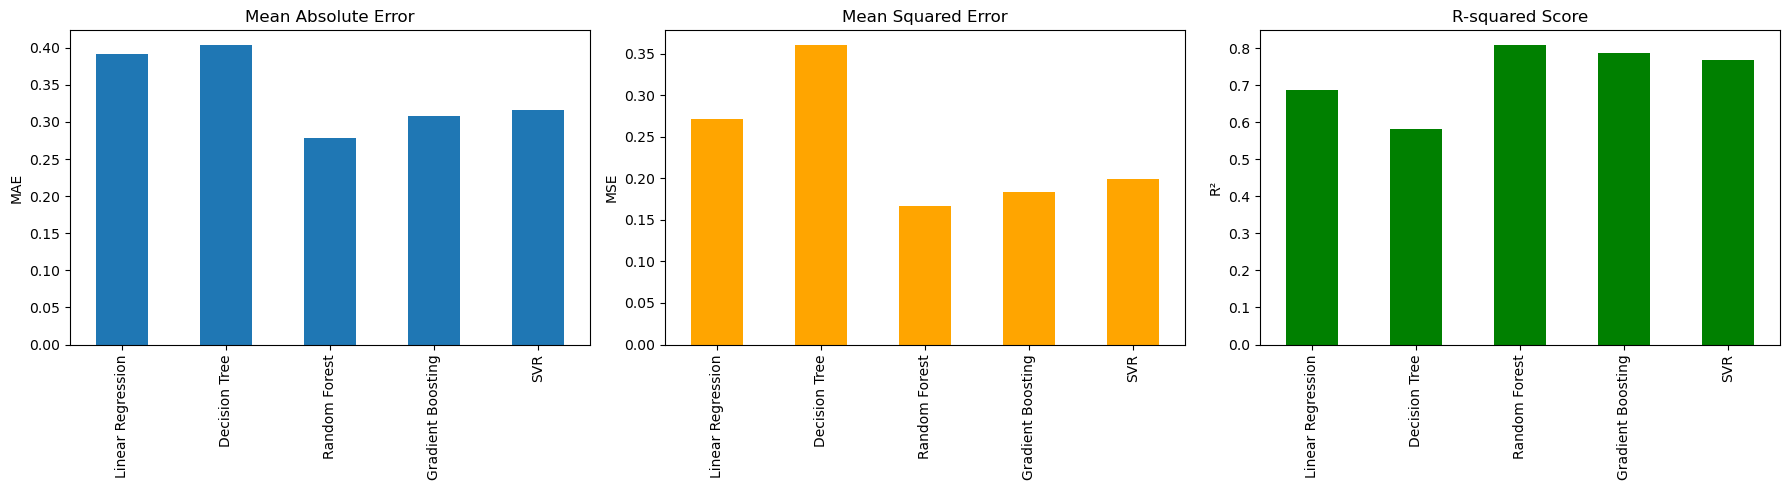

In [138]:
metrics_df = pd.DataFrame(results).T
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_df['MAE'].plot(kind='bar', ax=axes[0], title='Mean Absolute Error', ylabel='MAE')
metrics_df['MSE'].plot(kind='bar', ax=axes[1], title='Mean Squared Error', ylabel='MSE', color='orange')
metrics_df['R2'].plot(kind='bar', ax=axes[2], title='R-squared Score', ylabel='R²', color='green')

plt.tight_layout()
plt.show()

## 4. Cross-Validation and Hyperparameter Tuning

### 🔍 Random Forest Hyperparameter Tuning

### 🔍 Hyperparameter Tuning: Random Forest Regressor

We use GridSearchCV to perform 5-fold cross-validation over the following parameter grid:
- `n_estimators`: Number of trees in the forest.
- `max_depth`: Maximum depth of the tree (helps control overfitting).

Scoring is based on the **R² score**, and the best combination of parameters is selected based on average cross-validation performance.


In [151]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2')
grid_rf.fit(X, y)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Score:", grid_rf.best_score_)

Best RF Params: {'max_depth': 20, 'n_estimators': 100}
Best RF CV Score: 0.6105347051843172


### 🔍 Random Forest Regressor

**Hyperparameter Grid:**
- `n_estimators`: [50, 100] – Number of decision trees in the forest.
- `max_depth`: [10, 20, None] – Maximum depth of the individual trees.

**Best Parameters:**
```python
{'max_depth': 20, 'n_estimators': 100}

### 🔍 SVR Hyperparameter Tuning

In [152]:
param_grid_svr = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}
grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2')
grid_svr.fit(X, y)
print("Best SVR Params:", grid_svr.best_params_)

print("Best SVR CV Score:", grid_svr.best_score_)

Best SVR Params: {'C': 1, 'gamma': 'scale'}
Best SVR CV Score: 0.6402260269674563


Hyperparameter Grid:

C: [0.1, 1, 10] – Regularization strength.

gamma: ['scale', 'auto'] – Kernel coefficient for 'rbf'.

kernel: 'rbf' (default).

Best Parameters:{'C': 1, 'gamma': 'scale'}
Best Cross-Validation R² Score:0.6402

### Conclusion:
##### After tuning, SVR showed a better cross-validation score than Random Forest.

However, Random Forest still had better test accuracy (as shown in earlier evaluation metrics), suggesting that SVR might generalize better on some splits, while RF is more accurate on the full dataset.

##Final Model Selection
Based on test set performance and cross-validation results, we’ll summarize and recommend the best model.
## Test Set Performance (R² Score)
| Model             | R² Score     |
| ----------------- | ------------ |
| Linear Regression | 0.6859       |
| Decision Tree     | 0.5830       |
| **Random Forest** | **0.8075** ✅ |
| Gradient Boosting | 0.7871       |
| SVR               | 0.7687       |
### 🎯 Cross-Validation Scores

| Model         | CV R² Score |
| ------------- | ----------- |
| Random Forest | 0.6105      |
| SVR           | 0.6402 ✅    |


#### 🏆 Final Selection: Random Forest Regressor
✅ Why?

Best test performance (R² = 0.8075)

Low error (MAE = 0.2788, MSE = 0.1661)

Reasonably high CV score (0.6105)

Robust to non-linear data and less sensitive to outliers

